In [44]:
import sys
sys.path.insert(0, '/home/ethantu/good-vibrations')
from urllib.request import urlopen
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from datasets import Image
from matplotlib.colors import BoundaryNorm
from composer import Trainer
from composer.core import Evaluator
from composer.loggers import InMemoryLogger
from datasets import load_dataset
from plotly.subplots import make_subplots
from PIL import Image as PILImage

from src2.model import VibrationTransformer
from src2.dataset import build_dataset
from src2.callbacks import OutputSaver

# 0. Load Data

get the overhead images

In [2]:
REPO_ID = "eturok-weizmann/laser-vibrations"

In [3]:
ds = load_dataset(REPO_ID, split='train')
ds

Dataset({
    features: ['sample_id', 'segmented_overhead_file_name', 'speckle_vibrations_file_name', 'speckle_shifts_ifft_audio_file_name', 'audio_file_name', 'experiment_id', 'speakers', 'x_position', 'y_position', 'x_com', 'y_com', 'object', 'n_objects', 'box_material', 'mask_file_name', 'experiment_dir', 'manifest'],
    num_rows: 551
})

In [4]:
# there are issues with display the video and libtorchodec so we just look at the images in the dataset
img_ds = ds.cast_column("segmented_overhead_file_name", Image(decode=False)).select_columns(["segmented_overhead_file_name"])
overhead_img_paths = dict(zip(ds["sample_id"], [x["path"] for x in img_ds["segmented_overhead_file_name"]]))
overhead_img_paths[1]

'https://huggingface.co/datasets/eturok-weizmann/laser-vibrations/resolve/main/image/cube-000x-001y-1obj-cardboard-2026-03-31-18-21-24/segmented_overhead.png'

get the dataloaders

In [5]:
train_loader, eval_loader, _ = build_dataset(batch_size=10_000, eval_batch_size=10_000)
data_loaders = eval_loader+[Evaluator(label='train', dataloader=train_loader)]

Loaded dataset with 551 samples

x positions: [0 1 2 3 4 5 6 7 8 9 10 None]
y positions: [0 1 2 3 4 5 6 7 8 9 10 11 None]

Filtering dataset...
Final dataset contains 551 samples

Mask paths: ['image/cube-000x-001y-1obj-cardboard-2026-03-31-18-21-24/mask.npz', 'image/cube-000x-001y-1obj-cardboard-2026-03-31-18-21-22/mask.npz', 'image/cube-000x-001y-1obj-cardboard-2026-03-31-18-21-20/mask.npz', 'image/cube-000x-001y-1obj-cardboard-2026-03-31-18-21-18/mask.npz', 'image/cube-000x-002y-1obj-cardboard-2026-03-31-18-27-14/mask.npz']...
FFT paths: ['data/0000001/speckle_shifts_fft.npz', 'data/0000002/speckle_shifts_fft.npz', 'data/0000003/speckle_shifts_fft.npz', 'data/0000004/speckle_shifts_fft.npz', 'data/0000005/speckle_shifts_fft.npz']...


Fetching 1039 files:   0%|          | 0/1039 [00:00<?, ?it/s]

Downloaded snapshot to /home/ethantu/.cache/huggingface/hub/datasets--eturok-weizmann--laser-vibrations/snapshots/cd3612c5801878139c8e3edc5410e2088920c7c4

Loading masks and FFTs...
masks.shape=torch.Size([551, 956, 1069])	masks.dtype=torch.float32
fft.shape=torch.Size([551, 100, 3421, 2])	fft.dtype=torch.complex64

Discretizing masks...
masks.shape=torch.Size([551, 40, 20])	masks.dtype=torch.float32

Normalizing and patchifying FFTs...
fft.shape=torch.Size([551, 100, 13, 2, 256])	self.fft.dtype=torch.complex64

held_out_positions={(3, 4), (2, 2), (6, 6), (1, 9), (7, 8)}
551 total samples	416 train samples	105 eval samples	20 unseen position eval samples	10 multi-object eval samples

train_indices=[547, 189, 452, 353, 432, 294, 165, 442, 230, 376, 534, 501, 356, 293, 471, 380, 94, 204, 75, 530, 15, 234, 167, 196, 422, 19, 451, 56, 265, 418, 461, 170, 25, 274, 42, 336, 523, 366, 410, 134, 358, 31, 121, 438, 237, 425, 57, 528, 24, 17, 259, 66, 243, 390, 102, 221, 517, 23, 342, 287, 445, 

# 1. Inference

In [6]:
LOAD_PATH = '/home/ethantu/good-vibrations/runs/batman5/checkpoints/ep10000-ba70000-rank0.pt'

In [7]:
trainer = Trainer(model=VibrationTransformer(), load_path=LOAD_PATH, loggers=InMemoryLogger(), callbacks=OutputSaver("1ep", "dummy"), progress_bar=False)

/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/trainer/trainer.py:1224: UserWarning: No optimizer was specified. Defaulting to DecoupledSGDW(lr=0.1)
  warnings.warn((
/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/state.py:1580: UserWarning: InMemoryLogger is not in the state_dict. Its state will not be restored.
  warnings.warn(
/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/state.py:1388: UserWarning: DecoupledSGDW is not in the state_dict. Its state will not be restored.
  warnings.warn(


In [8]:
trainer.eval(data_loaders)
trainer.close()
del data_loaders
trainer.logger.destinations[0].data.keys()

/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 105 into batches of size 10000. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:29: UserWarning: Cannot split list of length 105 into batches of size 10000. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 20 into batches of size 10000. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu

dict_keys(['eval/base/fft', 'eval/base/mask_pred', 'eval/base/mask_true', 'eval/base/info', 'metrics/eval/base/mse', 'eval/unseen_pos/fft', 'eval/unseen_pos/mask_pred', 'eval/unseen_pos/mask_true', 'eval/unseen_pos/info', 'metrics/eval/unseen_pos/mse', 'eval/multi_object/fft', 'eval/multi_object/mask_pred', 'eval/multi_object/mask_true', 'eval/multi_object/info', 'metrics/eval/multi_object/mse', 'train/fft', 'train/mask_pred', 'train/mask_true', 'train/info', 'metrics/train/mse'])

# 2. Create Dataframe

In [9]:
def parse(label, outputs):
    out = {k:v for k, v in outputs.items() if label in k}
    return out | {f'{label}/{k}':v for k, v in out.pop(f'{label}/info').items()}

In [10]:
data = trainer.logger.destinations[0].most_recent_values
data = {k.replace('metrics/', ''): v for k, v in data.items()}
info_keys = [k for k in data.keys() if 'info' in k]
for info_key in info_keys: data |= {f'{info_key}/{k}':v for k, v in data.pop(info_key).items()}

print(data.keys())
for k, v in data.items(): print(f'{k}\t\t{v.shape if hasattr(v, 'shape') else v}')

dict_keys(['eval/base/fft', 'eval/base/mask_pred', 'eval/base/mask_true', 'eval/base/mse', 'eval/unseen_pos/fft', 'eval/unseen_pos/mask_pred', 'eval/unseen_pos/mask_true', 'eval/unseen_pos/mse', 'eval/multi_object/fft', 'eval/multi_object/mask_pred', 'eval/multi_object/mask_true', 'eval/multi_object/mse', 'train/fft', 'train/mask_pred', 'train/mask_true', 'train/mse', 'eval/base/info/sample_id', 'eval/base/info/x_position', 'eval/base/info/y_position', 'eval/base/info/n_objects', 'eval/base/info/speakers', 'eval/unseen_pos/info/sample_id', 'eval/unseen_pos/info/x_position', 'eval/unseen_pos/info/y_position', 'eval/unseen_pos/info/n_objects', 'eval/unseen_pos/info/speakers', 'eval/multi_object/info/sample_id', 'eval/multi_object/info/x_position', 'eval/multi_object/info/y_position', 'eval/multi_object/info/n_objects', 'eval/multi_object/info/speakers', 'train/info/sample_id', 'train/info/x_position', 'train/info/y_position', 'train/info/n_objects', 'train/info/speakers'])
eval/base/fft	

In [11]:
rows = []
tensor_store = []
for split in ["train", "eval/base", "eval/unseen_pos", "eval/multi_object"]:
    n = len(data[f"{split}/info/sample_id"])
    for i in range(n):
        sample_id = data[f"{split}/info/sample_id"][i].item()
        tensor_store.append({
            "fft": data[f"{split}/fft"][i],
            "mask_pred": data[f"{split}/mask_pred"][i],
            "mask_true": data[f"{split}/mask_true"][i],
        })
        rows.append({
            "tensor_idx": len(tensor_store) - 1,
            "split": split,
            "sample_id": sample_id,
            "segmented_overhead_path": overhead_img_paths[sample_id],
            "x_position": data[f"{split}/info/x_position"][i].item(),
            "y_position": data[f"{split}/info/y_position"][i].item(),
            "n_objects": data[f"{split}/info/n_objects"][i].item(),
            "speakers": data[f"{split}/info/speakers"][i],
        })
df = pd.DataFrame(rows)

In [12]:
df

,tensor_idx,split,sample_id,segmented_overhead_path,x_position,y_position,n_objects,speakers
0,0,train,216,https://huggingface.co/datasets/eturok-weizman...,5,1,1,1000
1,1,train,420,https://huggingface.co/datasets/eturok-weizman...,9,4,1,1000
2,2,train,284,https://huggingface.co/datasets/eturok-weizman...,6,7,1,1000
3,3,train,281,https://huggingface.co/datasets/eturok-weizman...,6,7,1,0001
4,4,train,204,https://huggingface.co/datasets/eturok-weizman...,4,9,1,1000
...,...,...,...,...,...,...,...,...
546,546,eval/multi_object,540,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,1000
547,547,eval/multi_object,541,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0001
548,548,eval/multi_object,542,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0010
549,549,eval/multi_object,543,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0100


# 3. Compute MSE

In [13]:
df["mse"] = [
    np.mean((np.asarray(tensor_store[i]["mask_pred"]) - np.asarray(tensor_store[i]["mask_true"])) ** 2)
    for i in df["tensor_idx"]
]

In [14]:
df

,tensor_idx,split,sample_id,segmented_overhead_path,x_position,y_position,n_objects,speakers,mse
0,0,train,216,https://huggingface.co/datasets/eturok-weizman...,5,1,1,1000,0.000004
1,1,train,420,https://huggingface.co/datasets/eturok-weizman...,9,4,1,1000,0.000008
2,2,train,284,https://huggingface.co/datasets/eturok-weizman...,6,7,1,1000,0.000004
3,3,train,281,https://huggingface.co/datasets/eturok-weizman...,6,7,1,0001,0.000004
4,4,train,204,https://huggingface.co/datasets/eturok-weizman...,4,9,1,1000,0.000007
...,...,...,...,...,...,...,...,...,...
546,546,eval/multi_object,540,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,1000,0.021996
547,547,eval/multi_object,541,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0001,0.029381
548,548,eval/multi_object,542,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0010,0.029159
549,549,eval/multi_object,543,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0100,0.029074


# 4. Compute center of mass

In [15]:
def com(mask):
    return np.average(np.arange(mask.shape[1]), weights=mask.sum(0) if mask.sum() > 0 else None), np.average(np.arange(mask.shape[0]), weights=mask.sum(1) if mask.sum() > 0 else None)
center_of_mass = []
for i in df.tensor_idx:
    px, py = com(tensor_store[i]["mask_pred"])
    tx, ty = com(tensor_store[i]["mask_true"])
    dx, dy = abs(px - tx), abs(py - ty)
    com_distance = (dx**2 + dy**2) ** 0.5
    center_of_mass.append((px, py, tx, ty, dx, dy, com_distance))

df[["pred_x_com", "pred_y_com", "true_x_com", "true_y_com", "x_com_diff", "y_com_diff", "com_dist"]] = center_of_mass
df

,tensor_idx,split,sample_id,segmented_overhead_path,x_position,y_position,n_objects,speakers,mse,pred_x_com,pred_y_com,true_x_com,true_y_com,x_com_diff,y_com_diff,com_dist
0,0,train,216,https://huggingface.co/datasets/eturok-weizman...,5,1,1,1000,0.000004,4.610751,16.848782,4.586174,16.819878,0.024577,0.028904,0.037941
1,1,train,420,https://huggingface.co/datasets/eturok-weizman...,9,4,1,1000,0.000008,8.682546,26.975365,8.674755,27.036840,0.007791,0.061475,0.061967
2,2,train,284,https://huggingface.co/datasets/eturok-weizman...,6,7,1,1000,0.000004,12.908029,19.234085,12.927776,19.220029,0.019746,0.014056,0.024238
3,3,train,281,https://huggingface.co/datasets/eturok-weizman...,6,7,1,0001,0.000004,12.913589,19.217321,12.927776,19.220029,0.014187,0.002708,0.014443
4,4,train,204,https://huggingface.co/datasets/eturok-weizman...,4,9,1,1000,0.000007,15.676525,14.433444,15.676532,14.405724,0.000007,0.027720,0.027720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,546,eval/multi_object,540,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,1000,0.021996,13.370202,22.345140,8.114332,16.935522,5.255869,5.409618,7.542422
547,547,eval/multi_object,541,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0001,0.029381,15.248536,14.376885,8.114332,16.935522,7.134204,2.558637,7.579148
548,548,eval/multi_object,542,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0010,0.029159,15.492915,14.241399,8.114332,16.935522,7.378583,2.694123,7.855048
549,549,eval/multi_object,543,https://huggingface.co/datasets/eturok-weizman...,-1,-1,5,0100,0.029074,14.384652,14.543629,12.193176,16.833828,2.191476,2.290199,3.169792


# 5. Compute Distance to speaker

# 6. Other

In [16]:
eval_base_df = df[df['split'] == 'eval/base']
eval_base_df

,tensor_idx,split,sample_id,segmented_overhead_path,x_position,y_position,n_objects,speakers,mse,pred_x_com,pred_y_com,true_x_com,true_y_com,x_com_diff,y_com_diff,com_dist
416,416,eval/base,528,https://huggingface.co/datasets/eturok-weizman...,8,-1,1,1000,0.017177,13.253849,29.703066,11.435260,21.801427,1.818589,7.901639,8.108216
417,417,eval/base,102,https://huggingface.co/datasets/eturok-weizman...,2,5,1,0010,0.000333,10.097428,9.114715,10.144785,9.224192,0.047357,0.109477,0.119281
418,418,eval/base,7,https://huggingface.co/datasets/eturok-weizman...,-1,2,1,0100,0.001971,6.265160,5.269651,6.046806,5.223628,0.218353,0.046023,0.223151
419,419,eval/base,258,https://huggingface.co/datasets/eturok-weizman...,6,1,1,0010,0.000004,4.616093,19.066446,4.601578,19.071479,0.014515,0.005032,0.015362
420,420,eval/base,99,https://huggingface.co/datasets/eturok-weizman...,2,4,1,0100,0.000304,8.963760,9.236087,8.866673,9.218759,0.097087,0.017329,0.098622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,516,eval/base,70,https://huggingface.co/datasets/eturok-weizman...,1,7,1,0010,0.000014,3.386827,9.339833,3.353859,9.359946,0.032968,0.020113,0.038619
517,517,eval/base,493,https://huggingface.co/datasets/eturok-weizman...,10,11,1,0001,0.000061,17.628249,29.972864,17.734836,30.077421,0.106586,0.104556,0.149307
518,518,eval/base,321,https://huggingface.co/datasets/eturok-weizman...,7,5,1,0001,0.008264,11.244064,21.619073,10.070416,21.869378,1.173648,0.250304,1.200042
519,519,eval/base,303,https://huggingface.co/datasets/eturok-weizman...,7,1,1,0100,0.004484,4.554059,22.652961,4.585821,21.790245,0.031762,0.862716,0.863300


compute the position distribution

In [17]:
def get_position_distribution(df, num_x_positions, num_y_positions, x_position_to_idx, y_position_to_idx):
    position_distribution = np.zeros((num_x_positions, num_y_positions), dtype=np.uint16)
    for x, y in zip(df['x_position'], df['y_position']): position_distribution[x_position_to_idx[x], y_position_to_idx[y]] += 1
    return position_distribution

In [18]:
splits = df['split'].unique().tolist()

In [19]:
num_x_positions, num_y_positions = len(df['x_position'].unique()), len(df['y_position'].unique())
x_position_to_idx = {x: idx for idx, x in enumerate(df['x_position'].unique())}
y_position_to_idx = {y: idx for idx, y in enumerate(df['y_position'].unique())}

position_distributions = {split: get_position_distribution(
    df[df['split'] == split], num_x_positions, num_y_positions, x_position_to_idx, y_position_to_idx) for split in splits}
position_distributions

{'train': array([[ 4,  4,  3,  3,  4,  3,  4,  3,  0,  2,  1,  4],
        [ 3,  4,  3,  4,  3,  4,  4,  4,  7,  3,  3,  3],
        [ 2,  4,  4,  3,  4,  4,  3,  0,  0,  4,  3,  3],
        [ 4,  0,  2,  4,  2,  3,  4,  3,  0,  3,  4,  3],
        [ 3,  4,  1,  0,  3,  0,  0,  4,  0,  2,  3,  4],
        [ 4,  3,  3,  4,  4,  4,  6,  4,  3,  4,  4,  4],
        [ 2,  4,  4,  3,  3,  3,  4,  3, 23,  3,  1,  3],
        [ 2,  7,  4,  4,  3,  3,  3,  4,  2,  0,  4,  1],
        [ 3,  2,  3,  4,  3,  4,  3,  4,  0,  3,  3,  0],
        [ 4,  3,  3,  3,  4,  3,  3,  4,  3,  3,  4,  4],
        [ 4,  0,  3,  3,  3,  3,  4,  3,  0,  4,  3,  3]], dtype=uint16),
 'eval/base': array([[0, 0, 1, 1, 0, 1, 0, 1, 0, 2, 3, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1],
        [2, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1],
        [0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 3, 0, 1, 4, 0, 0, 0, 2, 1, 0],
        [4, 1, 1, 0, 0, 0, 2, 0, 1, 0, 0, 0],
        [2, 0, 0, 1, 1, 1, 0, 1, 9, 1, 3, 1],
  

In [20]:
def plot_position_distribution(position_distribution, split, n_samples, total_samples, text, vmax=None):
    fig, ax = plt.subplots()

    vmax = int(position_distribution.max() if vmax is None else vmax)
    cmap = plt.get_cmap("viridis", vmax + 1)
    norm = BoundaryNorm(np.arange(-0.5, vmax + 1.5, 1), cmap.N)

    im = ax.imshow(position_distribution, origin="lower", cmap=cmap, norm=norm, aspect="auto")
    fig.colorbar(im, ax=ax, label="count", ticks=np.arange(0, vmax + 1))
    ax.set_title(f"euclidean_dist(COM(mask_pred), COM(mask_true))\n[{split}, n={n_samples}/{total_samples}]")
    ax.set(xlabel='Box width', ylabel='Box height')

    for (x, y), value in text.items():
        if value: ax.text(y, x, f'{value:.2f}', ha="center", va="center", color="white")
    return fig

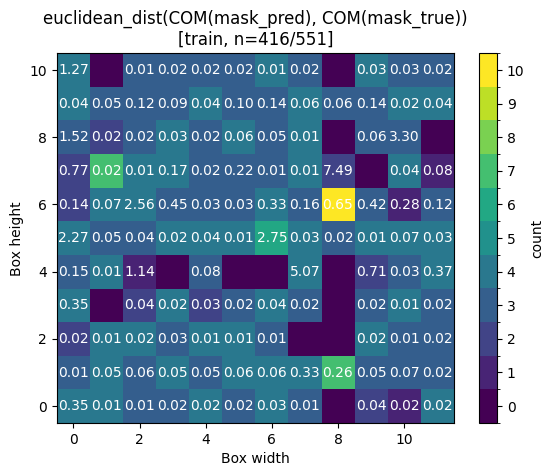

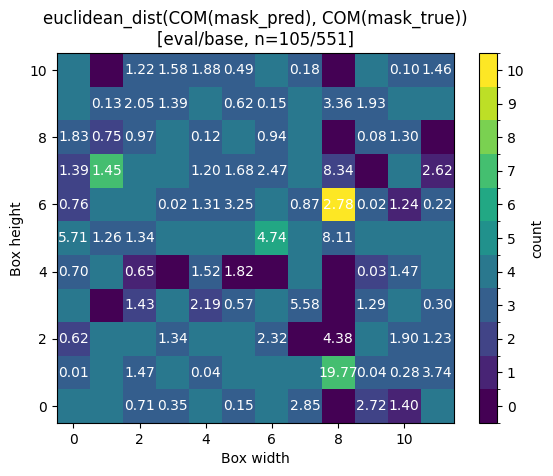

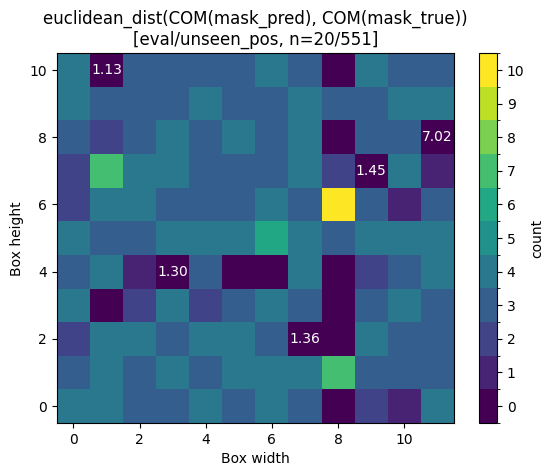

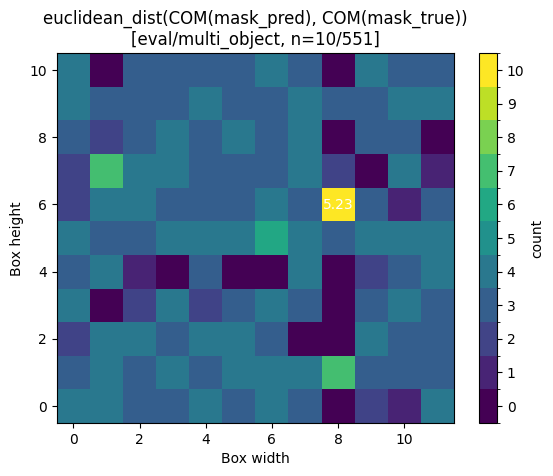

In [21]:
# compute max values across all distributions for consistent color scaling in the plots
vmax = int(max([dist.max() for split, dist in position_distributions.items()]))
vmax = 10

total_samples = len(df)
position_distribution_figs = {}
for split, position_distribution in position_distributions.items():
    split_df = df[df["split"] == split]
    com_distances = {(x_position_to_idx[x], y_position_to_idx[y]): com_dist
                     for (x, y), com_dist in (split_df.groupby(["x_position", "y_position"])["com_dist"].mean().items())}
    fig = plot_position_distribution(position_distributions['train'], split, len(df[df['split'] == split]), total_samples, com_distances, vmax)
    position_distribution_figs[split] = fig

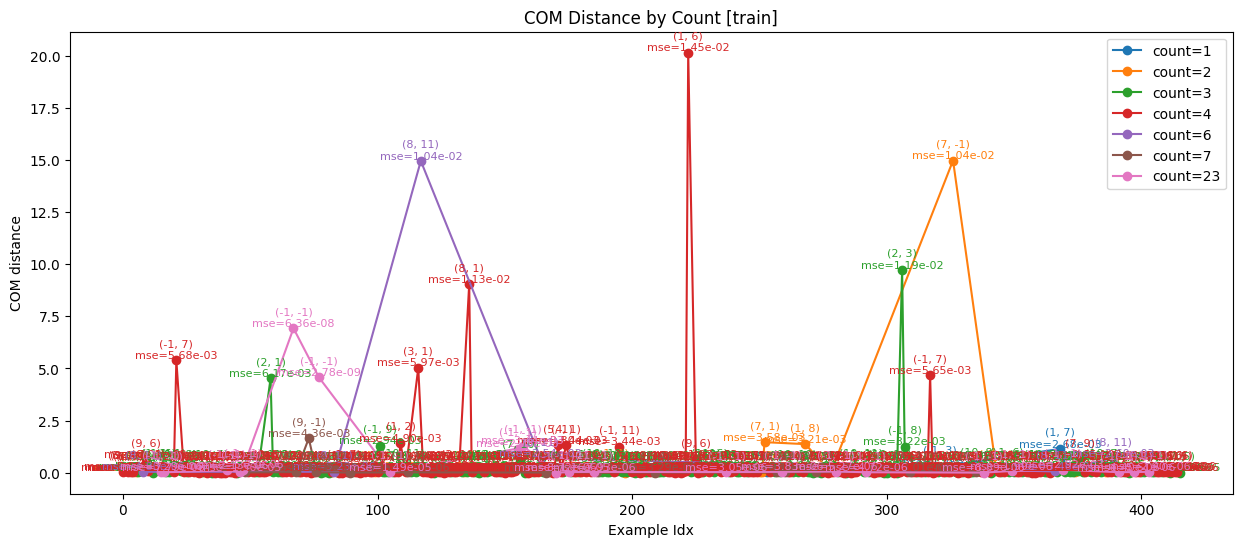

In [22]:
def plot_com_dist_by_count(split_df, split_name=None):
    plot_df = split_df.copy()
    plot_df["count"] = plot_df.groupby(["x_position", "y_position"])["x_position"].transform("size")
    plot_df["example_idx"] = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(15, 6))
    for count, sub_df in plot_df.groupby("count"):
        line, = ax.plot(sub_df["example_idx"], sub_df["com_dist"], marker="o", linestyle="-", label=f"count={count}")
        for _, row in sub_df.iterrows():
            ax.text(
                row["example_idx"],
                row["com_dist"],
                f'({row["x_position"]}, {row["y_position"]})\nmse={row["mse"]:.2e}',
                color=line.get_color(),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    ax.set_xlabel("Example Idx")
    ax.set_ylabel("COM distance")
    ax.set_title(f"COM Distance by Count [{split_name or 'split'}]")
    ax.legend()
    return fig, ax

fig, ax = plot_com_dist_by_count(df[df["split"] == "train"], "train")
plt.show()

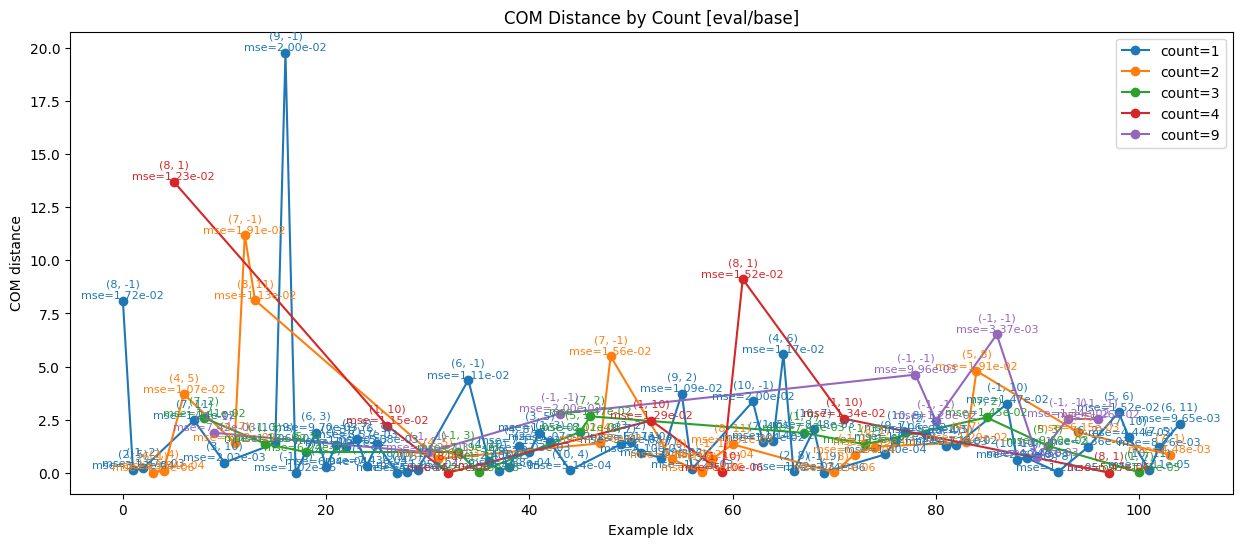

In [23]:
fig, ax = plot_com_dist_by_count(df[df["split"] == "eval/base"], "eval/base")
plt.show()

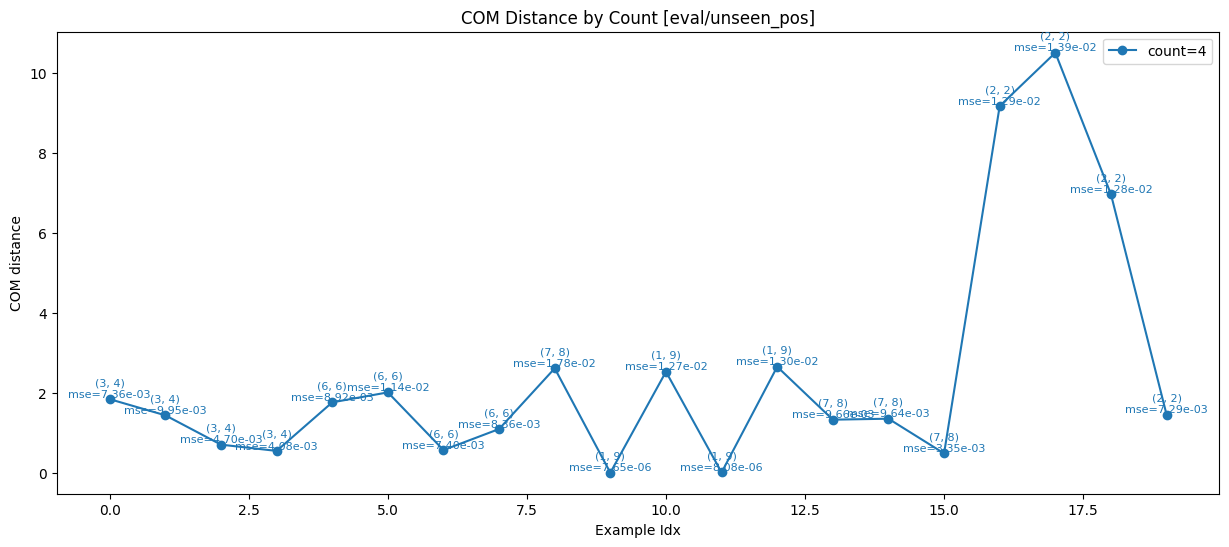

In [24]:
fig, ax = plot_com_dist_by_count(df[df["split"] == "eval/unseen_pos"], "eval/unseen_pos")
plt.show()

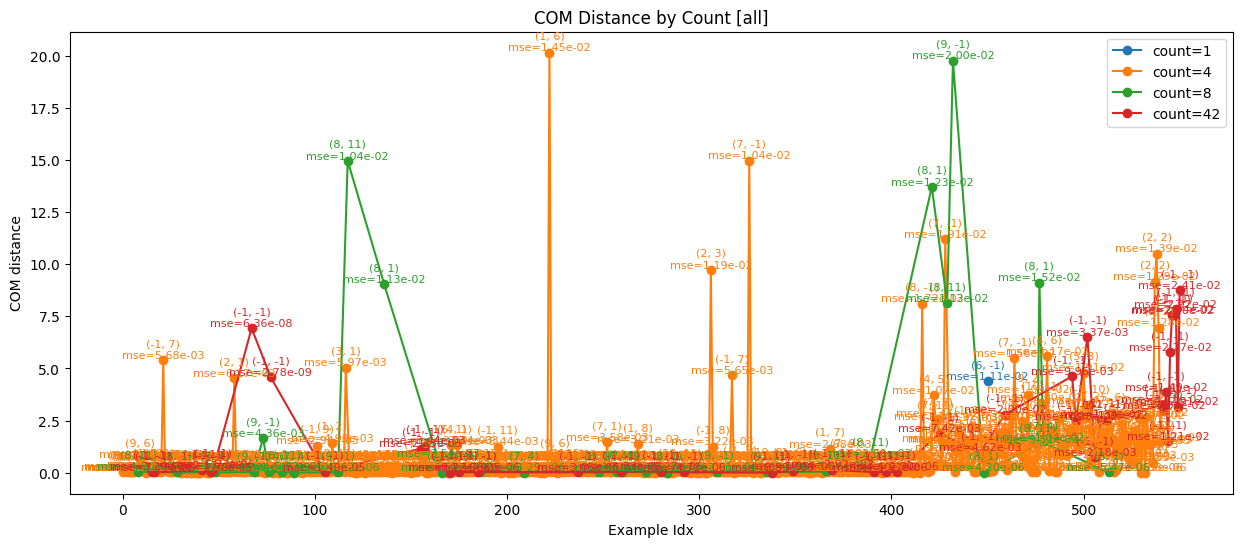

In [25]:
fig, ax = plot_com_dist_by_count(df, "all")
plt.show()

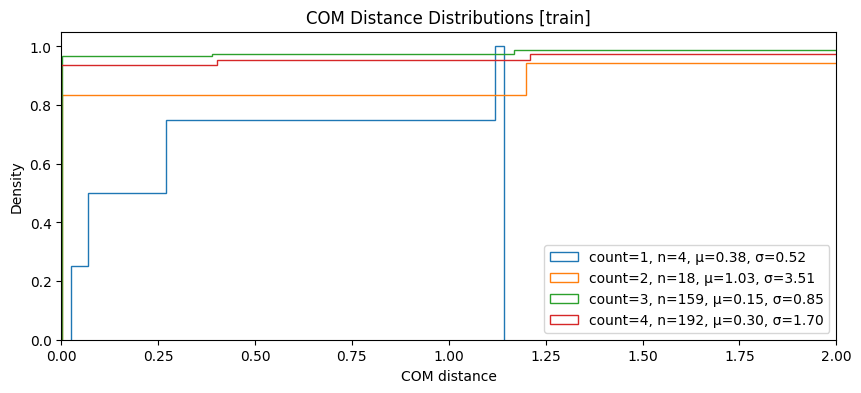

In [26]:
def plot_com_dist_distributions(split_df, split_name=None, bins=50):
    plot_df = split_df.copy()
    plot_df["count"] = plot_df.groupby(["x_position", "y_position"])["x_position"].transform("size")
    fig, ax = plt.subplots(figsize=(10, 4))
    for count, sub_df in plot_df.groupby("count"):
        if count > 4: continue
        mu = sub_df["com_dist"].mean()
        sigma = sub_df["com_dist"].std()
        weights = np.ones(len(sub_df)) / len(sub_df)
        ax.hist(sub_df["com_dist"], bins=bins, weights=weights,  cumulative=True, histtype="step",
                label=f"count={count}, n={len(sub_df)}, μ={mu:.2f}, σ={sigma:.2f}")
    ax.set(xlabel="COM distance", ylabel="Density", xlim=(0, 2))
    ax.set_title(f"COM Distance Distributions [{split_name or 'split'}]")
    ax.legend()
    return fig, ax

fig, ax = plot_com_dist_distributions(df[df["split"] == "train"], "train")
plt.show()

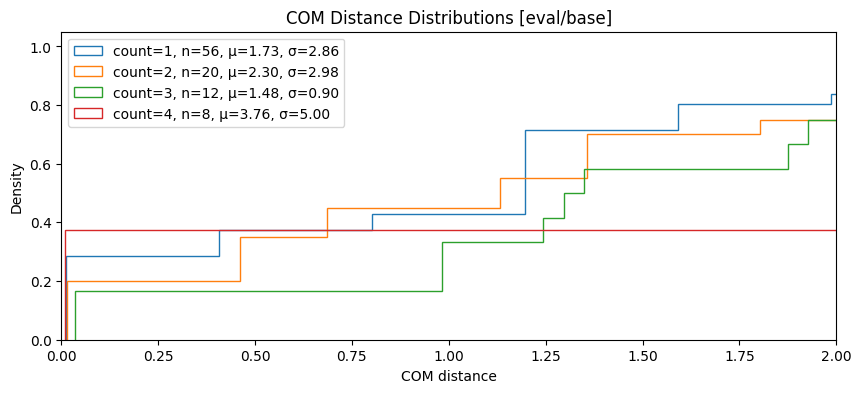

In [27]:
fig, ax = plot_com_dist_distributions(df[df["split"] == "eval/base"], "eval/base")
plt.show()

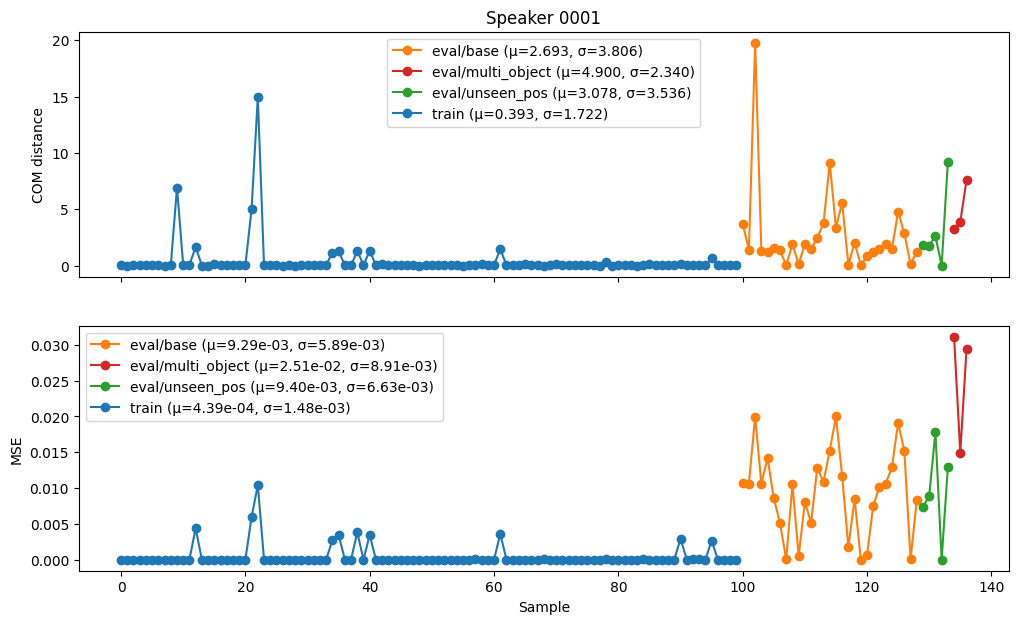

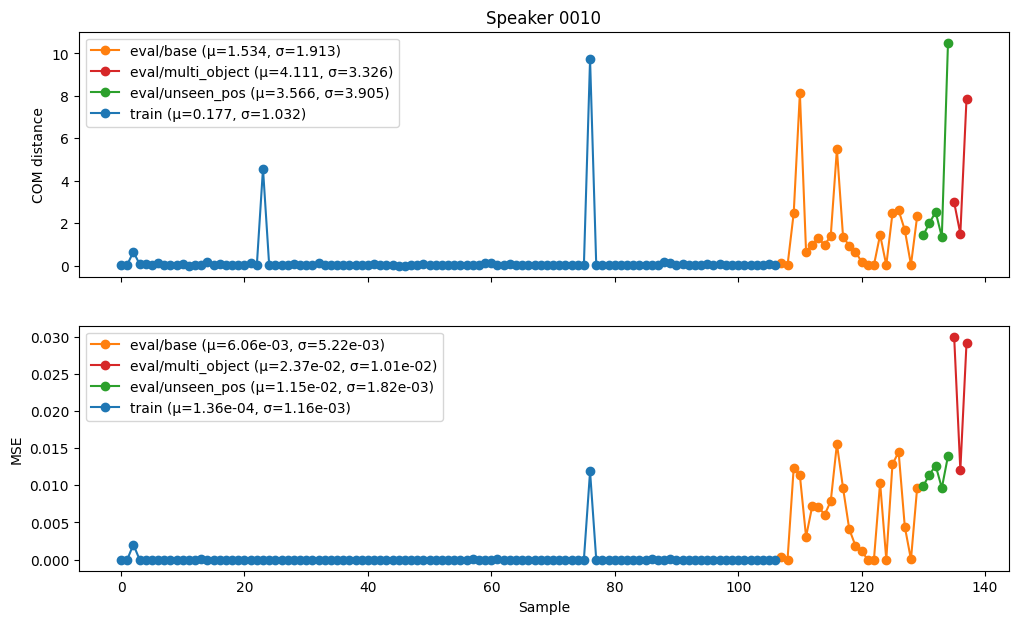

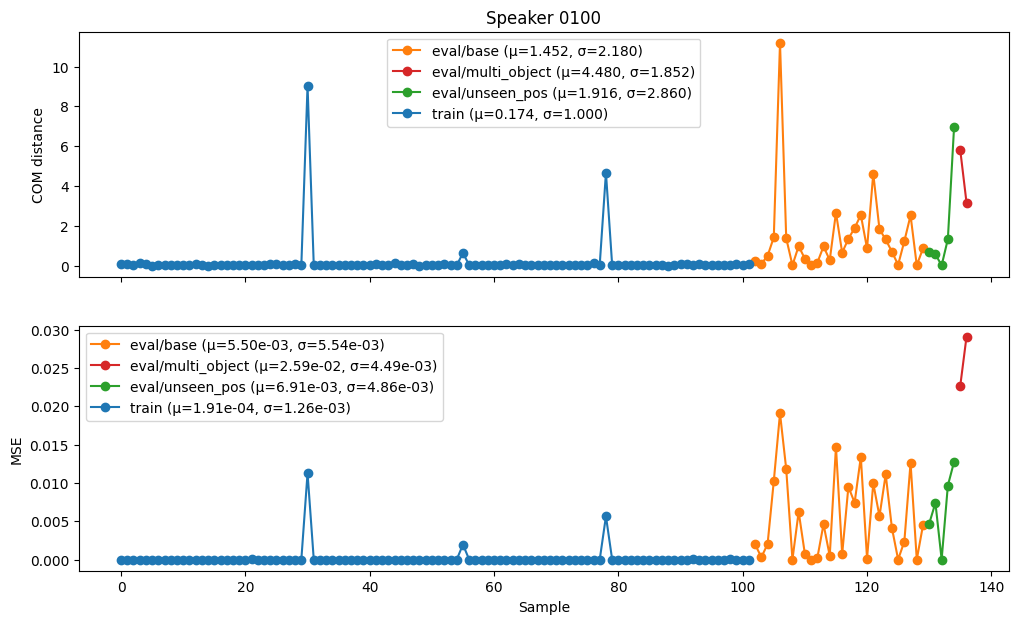

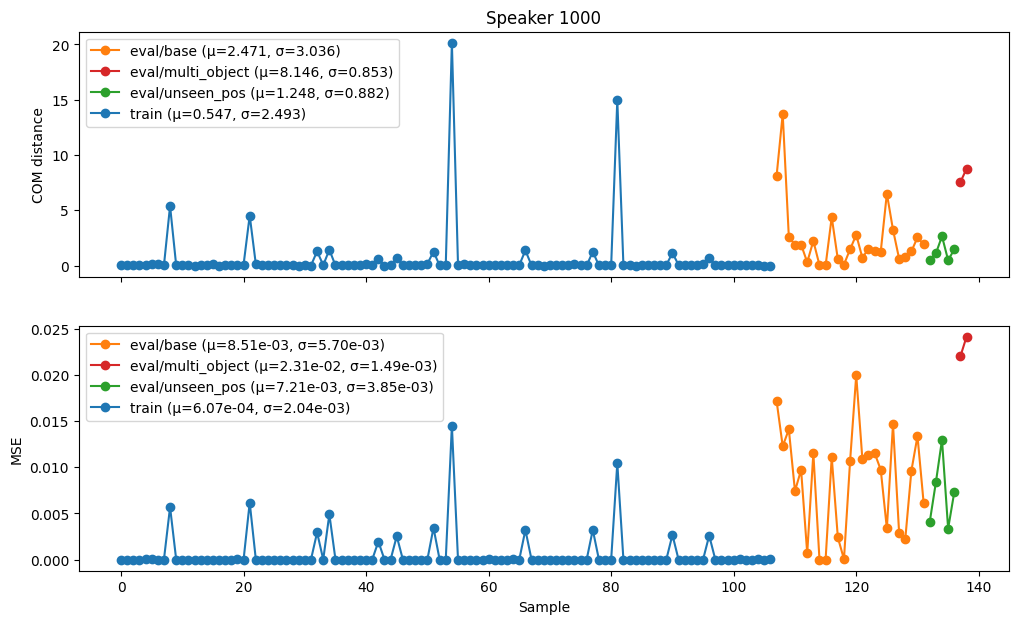

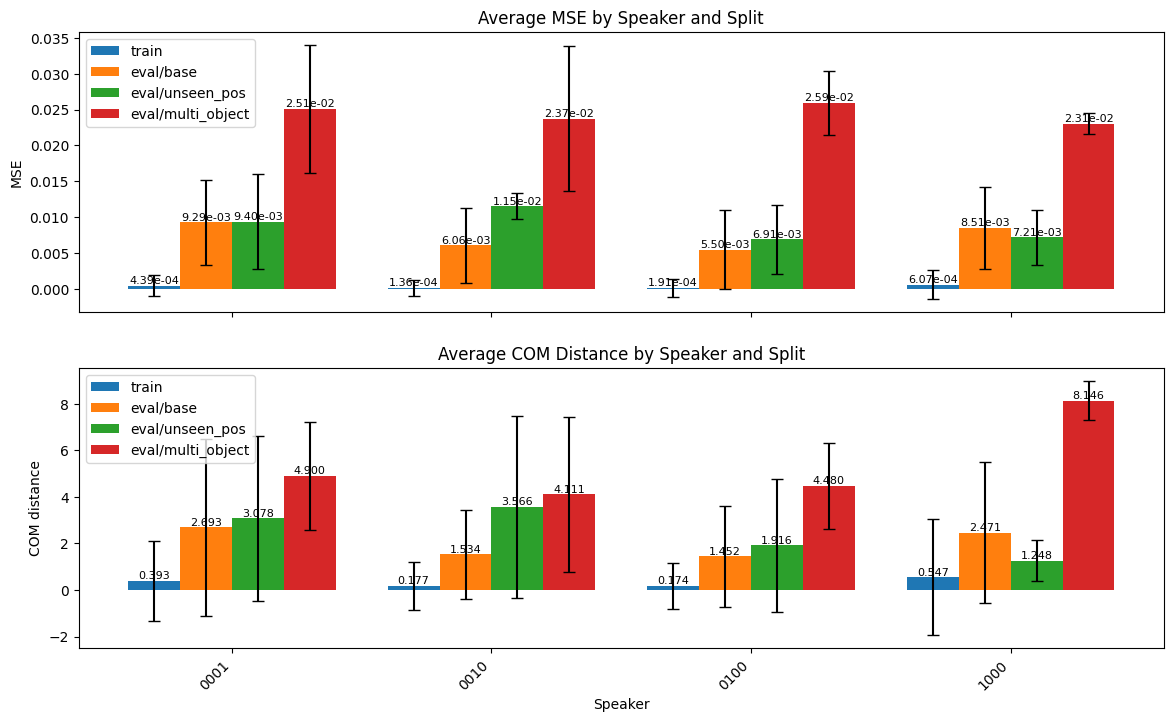

In [28]:
def plot_per_speaker(df):
    plot_df = df.copy()
    if plot_df["speakers"].map(lambda x: isinstance(x, (list, tuple, np.ndarray))).any(): plot_df = plot_df.explode("speakers")
    splits = plot_df["split"].drop_duplicates().tolist()
    colors = {split: f"C{i}" for i, split in enumerate(splits)}
    figs = {}
    for speaker, speaker_df in plot_df.groupby("speakers"):
        speaker_df = speaker_df.reset_index(drop=True)
        speaker_df["sample_idx"] = np.arange(len(speaker_df))
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        for split, sub_df in speaker_df.groupby("split"):
            ax1.plot(sub_df["sample_idx"], sub_df["com_dist"], marker="o", color=colors[split], label=f'{split} (μ={sub_df["com_dist"].mean():.3f}, σ={sub_df["com_dist"].std():.3f})')
            ax2.plot(sub_df["sample_idx"], sub_df["mse"], marker="o", color=colors[split], label=f'{split} (μ={sub_df["mse"].mean():.2e}, σ={sub_df["mse"].std():.2e})')
        ax1.set(title=f"Speaker {speaker}", ylabel="COM distance")
        ax2.set(xlabel="Sample", ylabel="MSE")
        ax1.legend()
        ax2.legend()
        figs[speaker] = (fig, (ax1, ax2))
    summary_df = plot_df.groupby(["speakers", "split"], as_index=False).agg(
        mean_com_dist=("com_dist", "mean"), std_com_dist=("com_dist", "std"),
        mean_mse=("mse", "mean"), std_mse=("mse", "std"),
    )
    speakers = summary_df["speakers"].drop_duplicates().tolist()
    x = np.arange(len(speakers))
    width = 0.8 / len(splits)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for i, split in enumerate(splits):
        sub_df = summary_df[summary_df["split"] == split].set_index("speakers").reindex(speakers).reset_index()
        offset = (i - (len(splits) - 1) / 2) * width
        bars1 = ax1.bar(x + offset, sub_df["mean_mse"], width, yerr=sub_df["std_mse"], capsize=4, color=colors[split], label=split)
        bars2 = ax2.bar(x + offset, sub_df["mean_com_dist"], width, yerr=sub_df["std_com_dist"], capsize=4, color=colors[split], label=split)
        for bar, mu, sigma in zip(bars1, sub_df["mean_mse"], sub_df["std_mse"]):
            if np.isnan(mu): continue
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mu:.2e}", ha="center", va="bottom", fontsize=8)
        for bar, mu, sigma in zip(bars2, sub_df["mean_com_dist"], sub_df["std_com_dist"]):
            if np.isnan(mu): continue
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mu:.3f}", ha="center", va="bottom", fontsize=8)
    ax1.set(title="Average MSE by Speaker and Split", ylabel="MSE")
    ax2.set(title="Average COM Distance by Speaker and Split", xlabel="Speaker", ylabel="COM distance")
    ax1.set_xticks(x, speakers)
    ax2.set_xticks(x, speakers)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    ax1.legend()
    ax2.legend()
    return figs, summary_df, (fig, (ax1, ax2))

figs, summary_df, summary_fig = plot_per_speaker(df)

In [29]:
summary_df

,speakers,split,mean_com_dist,std_com_dist,mean_mse,std_mse
0,0001,eval/base,2.692650,3.806320,0.009285,0.005888
1,0001,eval/multi_object,4.900158,2.340080,0.025127,0.008911
2,0001,eval/unseen_pos,3.077737,3.535611,0.009404,0.006634
3,0001,train,0.392601,1.721778,0.000439,0.001482
4,0010,eval/base,1.533839,1.913024,0.006063,0.005215
5,0010,eval/multi_object,4.111112,3.325939,0.023739,0.010132
6,0010,eval/unseen_pos,3.566480,3.904600,0.011532,0.001816
7,0010,train,0.176912,1.031521,0.000136,0.001162
8,0100,eval/base,1.451733,2.179547,0.005500,0.005545
9,0100,eval/multi_object,4.479521,1.852237,0.025897,0.004492


In [30]:
plt.close()

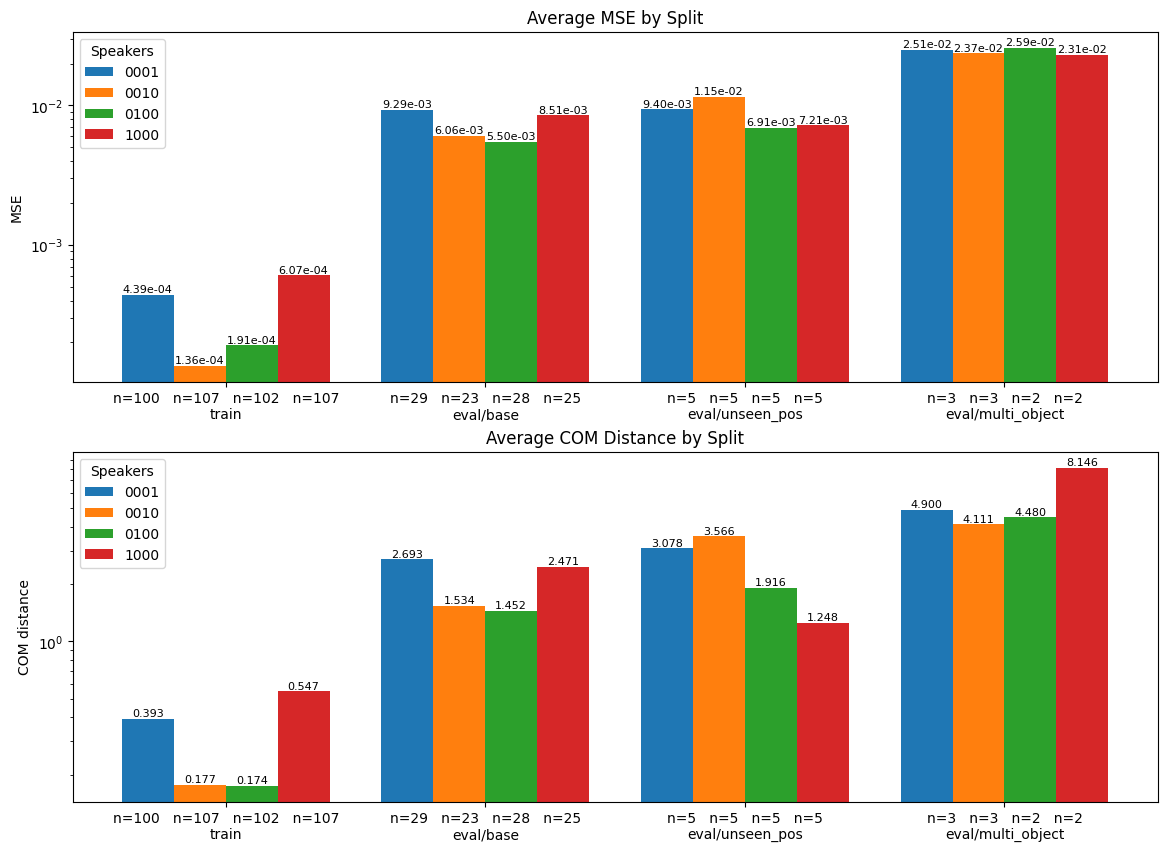

In [31]:
def plot_average_by_split(df):
    plot_df = df.copy()
    plot_df["speaker_key"] = plot_df["speakers"].map(lambda x: tuple(x) if isinstance(x, (list, tuple, np.ndarray)) else x)
    summary_df = plot_df.groupby(["split", "speaker_key"], as_index=False).agg(
        mean_com_dist=("com_dist", "mean"), std_com_dist=("com_dist", "std"),
        mean_mse=("mse", "mean"), std_mse=("mse", "std"),
        n_samples=("mse", "size"),
    )
    splits = [s for s in ["train", "eval/base", "eval/unseen_pos", "eval/multi_object"] if s in summary_df["split"].unique()]
    speakers = summary_df["speaker_key"].drop_duplicates().tolist()
    colors = {speaker: f"C{i}" for i, speaker in enumerate(speakers)}
    x = np.arange(len(splits))
    width = 0.8 / len(speakers)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    for i, speaker in enumerate(speakers):
        sub_df = summary_df[summary_df["speaker_key"] == speaker].set_index("split").reindex(splits).reset_index()
        offset = (i - (len(speakers) - 1) / 2) * width
        bars1 = ax1.bar(x + offset, sub_df["mean_mse"], width, color=colors[speaker], label=str(speaker))
        bars2 = ax2.bar(x + offset, sub_df["mean_com_dist"], width, color=colors[speaker], label=str(speaker))
        for bar, mu in zip(bars1, sub_df["mean_mse"]):
            if not np.isnan(mu): ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mu:.2e}", ha="center", va="bottom", fontsize=8)
        for bar, mu in zip(bars2, sub_df["mean_com_dist"]):
            if not np.isnan(mu): ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mu:.3f}", ha="center", va="bottom", fontsize=8)
    tick_labels = []
    for split in splits:
        sub_df = summary_df[summary_df["split"] == split]
        counts = "   ".join(f"n={int(sub_df[sub_df['speaker_key'] == speaker]['n_samples'].iloc[0])}" for speaker in speakers if (sub_df["speaker_key"] == speaker).any())
        tick_labels.append(f"{counts}\n{split}")
    ax1.set(title="Average MSE by Split", ylabel="MSE", yscale="log")
    ax2.set(title="Average COM Distance by Split", ylabel="COM distance", yscale="log")
    ax1.set_xticks(x, tick_labels)
    ax2.set_xticks(x, tick_labels)
    ax1.tick_params(axis="x", labelbottom=True)
    plt.setp(ax1.get_xticklabels(), ha="center")
    plt.setp(ax2.get_xticklabels(), ha="center")
    ax1.legend(title="Speakers")
    ax2.legend(title="Speakers")
    return summary_df, (fig, (ax1, ax2))

summary_df, summary_fig = plot_average_by_split(df)
plt.show()

# Sample Viewer

In [45]:
SPEAKER_DIR = Path('/home/ethantu/good-vibrations/assets/speakers')

In [46]:
def crop_padded_overhead(img):
    speaker_icon = PILImage.open(SPEAKER_DIR / "speaker.png")
    icon_aspect = speaker_icon.size[0] / speaker_icon.size[1]
    padded_h, padded_w = img.shape[:2]
    inner_h = round(padded_h / 1.4)
    icon_h = padded_h - inner_h
    icon_w = round(icon_aspect * icon_h)
    inner_w = padded_w - icon_w
    x0, y0 = icon_w // 2, icon_h // 2
    x1, y1 = x0 + inner_w, y0 + inner_h
    return x0, y0, x1, y1

In [ ]:
def plot_sample_row(row, tensor_store):
    pred = np.asarray(tensor_store[row["tensor_idx"]]["mask_pred"], dtype=float)
    true = np.asarray(tensor_store[row["tensor_idx"]]["mask_true"], dtype=float)
    assert true.shape == pred.shape
    diff = pred - true

    mask_h, mask_w = true.shape
    x, y = np.arange(mask_w), np.arange(mask_h)
    img = np.asarray(PILImage.open(urlopen(row["segmented_overhead_path"])).convert("RGB"))
    x0, y0, x1, y1 = crop_padded_overhead(img)
    print(f'{x0=}, {y0=}, {x1=}, {y1=}')
    x_img = np.linspace(x0, x1, mask_w, endpoint=False) + (x1 - x0) / (2 * mask_w)
    y_img = np.linspace(y0, y1, mask_h, endpoint=False) + (y1 - y0) / (2 * mask_h)

    sample_id, split, n_objects, pos = int(row["sample_id"]), row["split"], int(row["n_objects"]), (int(row["x_position"],), int(row["y_position"]))
    mse, dist_com = float(row["mse"]), float(row["com_dist"])
    pred_com, true_com, diff_com = (float(row["pred_x_com"]), float(row["pred_y_com"])), (float(row["true_x_com"]), float(row["true_y_com"])), (float(row["x_com_diff"]), float(row["y_com_diff"]))
    title = f"{sample_id=}, {split=}, {n_objects=}, {pos=}<br>{mse=:.2e}, pred_com=({pred_com[0]:.2f}, {pred_com[1]:.2f}), true_com=({true_com[0]:.2f}, {true_com[1]:.2f}), {dist_com=:.2f}"
    subplot_titles = ("Overhead", f"Ground Truth com=({true_com[0]:.2f}, {true_com[1]:.2f})", f"Predicted Mask com=({pred_com[0]:.2f}, {pred_com[1]:.2f})", f"Diff com=({diff_com[0]:.2f}, {diff_com[1]:.2f})")

    fig = make_subplots(rows=1, cols=4, subplot_titles=subplot_titles, horizontal_spacing=0.1)

    fig.add_trace(go.Image(z=img, hoverinfo="skip"), row=1, col=1)
    fig.add_trace(go.Heatmap(z=pred, zmin=0, zmax=1, x=x_img, y=y_img, zsmooth=False, colorscale=[[0, "rgba(255,0,0,0)"], [1, "rgba(255,0,0,1)"]], showscale=True,
                             colorbar=dict(title="pred", x=0.17, len=0.75, y=0.5, ticklabelposition="inside"),
                             hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.4f}<extra></extra>"), row=1, col=1)
    fig.add_trace(go.Heatmap(z=true, zmin=0, zmax=1, x=x, y=y, colorscale="Blues", showscale=True,
                             colorbar=dict(title="true", x=0.47, len=0.75, y=0.5, ticklabelposition="inside"),
                             hovertemplate="x=%{x}<br>y=%{y}<br>true=%{z:.4f}<extra></extra>"), row=1, col=2)
    fig.add_trace(go.Heatmap(z=pred, zmin=0, zmax=1, x=x, y=y, colorscale="Reds", showscale=True,
                             colorbar=dict(title="pred", x=0.73, len=0.75, y=0.5, ticklabelposition="inside"),
                             hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.4f}<extra></extra>"), row=1, col=3)
    fig.add_trace(go.Heatmap(z=diff, zmin=-max(np.abs(diff).max(), 1e-6), zmax=max(np.abs(diff).max(), 1e-6), x=x, y=y, colorscale="RdBu", showscale=True,
                             colorbar=dict(title="diff", x=0.99, len=0.75, y=0.5, ticklabelposition="inside"),
                             hovertemplate="x=%{x}<br>y=%{y}<br>diff=%{z:.4f}<extra></extra>"), row=1, col=4)
    fig.update_layout(title=title, width=1500, height=450, plot_bgcolor="white", paper_bgcolor="white")
    fig.update_xaxes(showgrid=False, zeroline=False, showline=False, title="box height y")
    fig.update_yaxes(showgrid=False, zeroline=False, showline=False, title="box width x", autorange="reversed")
    return fig

In [100]:
fig = plot_sample_row(df.iloc[2], tensor_store)
fig.show()